d. Nhóm câu hỏi về Đặc điểm User và Điểm chạm (User Demographics & Touchpoints)
- Khoảng cách ra quyết định (Conversion Time): Có sự khác biệt về chất lượng (số lượng giao dịch, số tiền chi) giữa nhóm NPU vừa tạo tài khoản (created_account_date) xong là giao dịch ngay, so với nhóm tài khoản đã tạo từ lâu "ngủ đông" nay mới bị đánh thức bởi campaign không?

- Sự khác biệt giới tính: Đặc thù chi tiêu và tỷ lệ giữ chân giữa người dùng Nam và Nữ có sự chênh lệch đáng kể nào trong từng Campaign cụ thể không?


## **Xử lý dữ liệu**

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
data = pd.read_csv('Data/Processed/result_clean.csv')

# Display basic information about the dataset
print(data.info())

# Print the first few rows of the dataset
print(data.head())

<class 'pandas.DataFrame'>
RangeIndex: 271782 entries, 0 to 271781
Data columns (total 18 columns):
 #   Column                Non-Null Count   Dtype
---  ------                --------------   -----
 0   transID               271782 non-null  str  
 1   userID                271782 non-null  str  
 2   sof                   271782 non-null  str  
 3   platform              271782 non-null  str  
 4   appID                 271782 non-null  int64
 5   deviceID              271782 non-null  str  
 6   userIP                271782 non-null  str  
 7   reqDate               271782 non-null  str  
 8   amount                271782 non-null  int64
 9   userChargeAmount      271782 non-null  int64
 10  discountAmount        271782 non-null  int64
 11  transStatus           271782 non-null  int64
 12  campaignID            271782 non-null  int64
 13  promotion_type        271782 non-null  str  
 14  gender                271782 non-null  str  
 15  created_account_date  271782 non-null  str  


In [42]:
data.shape[0]

271782

- Khoảng cách ra quyết định (Conversion Time): Có sự khác biệt về chất lượng (số lượng giao dịch, số tiền chi) giữa nhóm NPU vừa tạo tài khoản (created_account_date) xong là giao dịch ngay, so với nhóm tài khoản đã tạo từ lâu "ngủ đông" nay mới bị đánh thức bởi campaign không?

PHẦN 1: TỪNG BƯỚC XỬ LÝ DỮ LIỆU (Data Pipeline)
Quá trình này biến cái "Master Table" của bạn thành những con số biết nói, bám sát bộ tiêu chí R.E.M.P.B.

Bước 1: Clean & Filter (Xác định đúng giao dịch NPU)

Sắp xếp toàn bộ dữ liệu theo userID và reqDate (từ cũ tới mới).

Đánh dấu giao dịch đầu tiên (first_request = True).

Lọc bắt buộc: Chỉ giữ lại những userID mà tại dòng first_request = True, cột discountAmount > 0 hoặc có campaignID rõ ràng. (Đúng yêu cầu của đề: NPU phải dùng promotion).


🔴 DANH SÁCH CẦN LOẠI BỎ (Không sinh doanh thu hoặc không hợp lệ)
Khi lọc dữ liệu, bạn bắt buộc phải loại bỏ các subcat sau khỏi tập khách hàng NPU của mình:
Giao dịch nội bộ (Luân chuyển tiền của hệ thống/Nhân sự):
Internal_Service_Education
Internal_Service_Facility
Internal_Service_Internal_Use
Giao dịch lỗi/Chưa xác định (Làm nhiễu data):
Toàn bộ các mã có đuôi Unknown_Type (nằm rải rác ở các category).
Unknown_Group
Quyên góp từ thiện (Không thu phí/MDR = 0%):
Social_Service_Contribution (Lưu ý: Đây đúng là thanh toán dịch vụ, nhưng các ví điện tử tại VN đều miễn phí 100% cho tổ chức từ thiện, nên nó tạo ra dòng tiền nhưng không tạo ra Doanh thu).


In [ ]:
# Filter out excluded categories/subcategories if present.
exclude_values = [
    'Internal_Service_Education',
    'Internal_Service_Facility',
    'Internal_Service_Internal_Use',
    'Unknown_Group',
    'Social_Service_Contribution',
]

# Remove any rows where category or subcategory matches the excluded list.
category_cols = [col for col in ['category', 'report_cat'] if col in data.columns]
subcat_cols = [col for col in ['subcat', 'report_sub_cat', 'report_subcat'] if col in data.columns]

for col in category_cols:
    data = data[~data[col].isin(exclude_values)].copy()
for col in subcat_cols:
    data = data[~data[col].isin(exclude_values)].copy()

# Remove any Unknown_Type subcategories (suffix match).
for col in subcat_cols:
    data = data[~data[col].astype(str).str.endswith('Unknown_Type', na=False)].copy()

In [44]:
data.shape[0]

271782

In [33]:
import pandas as pd

# 1. Chuyển đổi cột sang datetime
data['reqDate'] = pd.to_datetime(data['reqDate'], errors='coerce')
data['created_account_date'] = pd.to_datetime(data['created_account_date'], format='%Y-%m-%d', errors='coerce')

# 2. Tính toán số ngày giữa reqDate và created_account_date
data['days_between'] = (data['reqDate'] - data['created_account_date']).dt.days

# 3. BẮT BUỘC SẮP XẾP dữ liệu theo userID và reqDate (từ cũ tới mới)
# Bước này cực kỳ quan trọng để đảm bảo dòng đầu tiên xuất hiện của mỗi user CHÍNH LÀ giao dịch đầu tiên
data = data.sort_values(by=['userID', 'reqDate'])

# 4. Gán label first_request:
# .cumcount() sẽ đánh số thứ tự giao dịch (0, 1, 2...). Giao dịch số 0 chính là first_request.
data['first_request'] = (data.groupby('userID').cumcount() == 0) & (data['days_between'] >= 0)

# 5. Lọc ra những user có giao dịch đầu tiên nhưng không dùng promotion (campaignID là 0) để bỏ đi thẳng trong data
data = data[~((data['first_request']) & (data['campaignID'] == 0))]

# Lưu lại kết quả
data.to_csv('Data/Processed/result_without_user_no_promotion.csv', index=False)

# Lọc riêng mỗi dòng là 1 giao dịch đầu tiên của user để kiểm tra
first_requests = data[data['first_request']]
# Lưu ra file riêng để kiểm tra
first_requests.to_csv('Data/Processed/first_requests.csv', index=False)

# In ra kết quả kiểm tra, sort theo days_between để xem rõ ràng hơn
print(data[['userID', 'reqDate', 'created_account_date', 'days_between', 'first_request']].sort_values(by=['userID', 'days_between']))

                                  userID                 reqDate  \
215184  000046fd1fef54ddbc605a4a98594da3 2022-08-09 02:16:50.026   
256335  000046fd1fef54ddbc605a4a98594da3 2022-08-09 02:37:28.861   
208402  000046fd1fef54ddbc605a4a98594da3 2022-08-21 16:32:45.346   
95352   000046fd1fef54ddbc605a4a98594da3 2022-08-24 15:20:32.559   
149041  000046fd1fef54ddbc605a4a98594da3 2022-12-05 07:19:50.108   
...                                  ...                     ...   
241494  ffff30190f8c6d362c9531f8e5c54235 2022-08-31 15:21:05.119   
268802  ffff30190f8c6d362c9531f8e5c54235 2022-11-06 17:50:06.792   
212731  ffff30190f8c6d362c9531f8e5c54235 2022-11-06 20:04:54.753   
13312   ffff30190f8c6d362c9531f8e5c54235 2022-11-11 06:58:42.422   
67244   ffff30190f8c6d362c9531f8e5c54235 2022-11-16 12:06:07.502   

       created_account_date  days_between  first_request  
215184           2021-09-25           318           True  
256335           2021-09-25           318          False  
208402

In [34]:
data.info()

<class 'pandas.DataFrame'>
Index: 271752 entries, 215184 to 67244
Data columns (total 20 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   transID               271752 non-null  str           
 1   userID                271752 non-null  str           
 2   sof                   271752 non-null  str           
 3   platform              271752 non-null  str           
 4   appID                 271752 non-null  int64         
 5   deviceID              271752 non-null  str           
 6   userIP                271752 non-null  str           
 7   reqDate               271752 non-null  datetime64[us]
 8   amount                271752 non-null  int64         
 9   userChargeAmount      271752 non-null  int64         
 10  discountAmount        271752 non-null  int64         
 11  transStatus           271752 non-null  int64         
 12  campaignID            271752 non-null  int64         
 13  promotion_t

Thống kê mô tả của cột days_between:
count    33613.000000
mean       440.804808
std        388.074753
min          0.000000
25%         16.000000
50%        452.000000
75%        721.000000
max       2266.000000
Name: days_between, dtype: float64


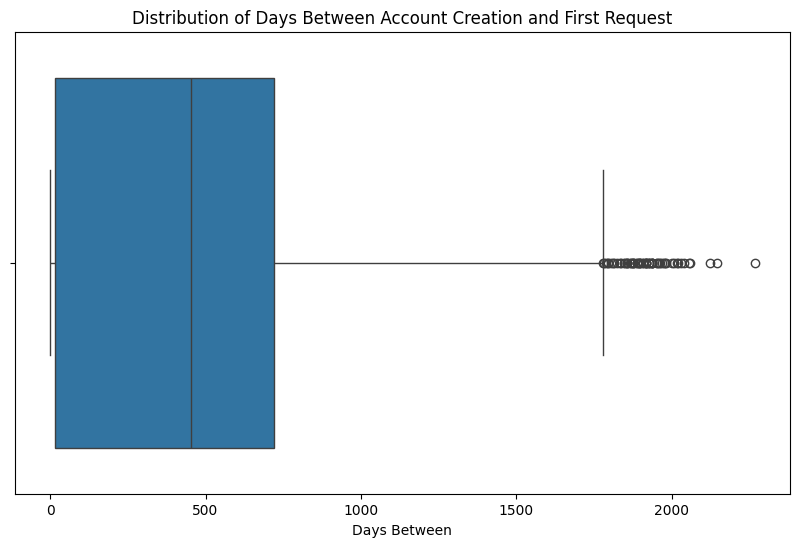

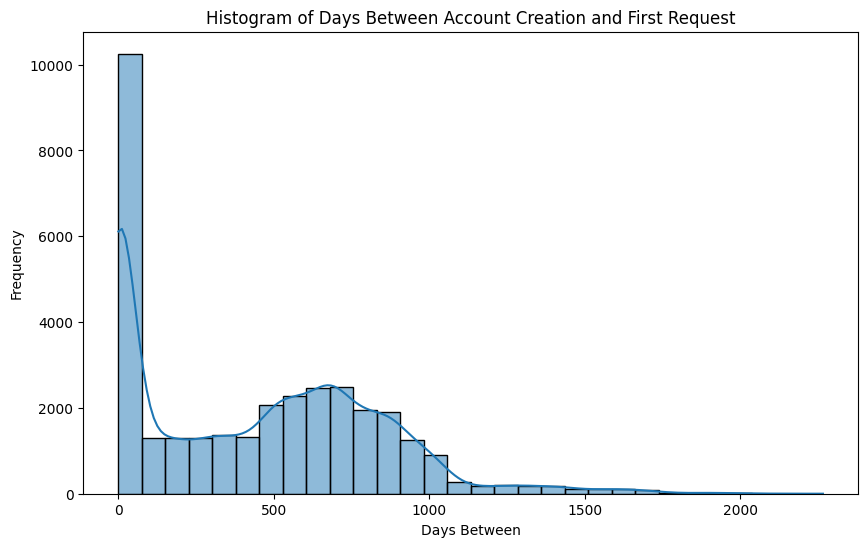

In [35]:
# In ra thống kê mô tả của cột days_between trong first_requests để xem phân phối như thế nào
print("Thống kê mô tả của cột days_between:")
print(first_requests['days_between'].describe())

# Vẽ phân phối days_between bằng boxplot xem các khoảng tứ phân vị và outliers như thế nào
plt.figure(figsize=(10, 6))
sns.boxplot(x=first_requests['days_between'])
plt.title('Distribution of Days Between Account Creation and First Request')
plt.xlabel('Days Between')
plt.show()

# Vẽ histogram để xem phân phối chi tiết hơn
plt.figure(figsize=(10, 6))
sns.histplot(first_requests['days_between'], bins=30, kde=True)
plt.title('Histogram of Days Between Account Creation and First Request')
plt.xlabel('Days Between')
plt.ylabel('Frequency')
plt.show()

## **Nhận xét**:

- Với Median (50%) là 452 ngày và Q3 (75%) là 721 ngày, điều này có nghĩa là hơn một nửa số NPU trong tập dữ liệu này đã tạo tài khoản từ hơn 1 năm (thậm chí 2 năm) trước rồi mới chịu phát sinh giao dịch đầu tiên.

=> Các chiến dịch NPU trong khoảng thời gian này mang đậm tính chất "Đánh thức người dùng cũ" (Re-activation/Awakening) hơn là "Thu hút người dùng mới tải app" (New Acquisition).

- Có thể chia nhóm người dùng dựa trên độ tuổi tài khoản:
1. Nhóm Onboarding (Giao dịch ngay): 0 - 16 ngày
Cơ sở dữ liệu: Chốt ngay mốc Q1 (25% = 16 ngày).

Giải thích: Đây là top 25% user hành động nhanh nhất. Mốc 16 ngày (khoảng 2 tuần) là một khoảng thời gian "trăng mật" hoàn toàn hợp lý trong Fintech để người dùng tải app, eKYC, ngâm cứu ứng dụng và quyết định nạp tiền.

2. Nhóm Delayed (Chuyển đổi chậm): 17 - 90 ngày

Cơ sở dữ liệu: Nằm giữa Q1 và tiệm cận mức 3 tháng.

Giải thích: Tài khoản đã qua giai đoạn trăng mật nhưng chưa hoàn toàn bị lãng quên. Họ có thể đã tải app vì một lý do nào đó trong quá khứ gần, nhưng cần một "cú hích" (voucher campaign) từ 1-3 tháng sau để thực sự kích hoạt.

3. Nhóm Dormant (Ngủ đông): 91 - 365 ngày

Cơ sở dữ liệu: Từ 3 tháng đến 1 năm.
Giải thích: Tài khoản đã thực sự chìm vào giấc ngủ. Đưa mốc 1 năm vào làm ranh giới sẽ rất dễ giải thích và bám sát tư duy báo cáo thường niên của doanh nghiệp.

4. Nhóm Deep Dormant (Ngủ đông sâu): > 365 ngày

Cơ sở dữ liệu: Ôm trọn nhóm từ sau mốc 1 năm đến max (2266 ngày). Vì Median là 452 ngày, nhóm này sẽ chiếm hơn 50% tổng số user của bạn.

Giải thích: Đây là những "hóa thạch" từ thời kỳ đầu của Zalopay (2017-2018) nay mới được đánh thức. Việc phân tách riêng nhóm này giúp bạn trả lời một câu hỏi lớn: Đổ tiền marketing để "gọi hồn" những user tạo tài khoản từ 3-4 năm trước có thực sự mang lại ROI tốt không, hay họ chỉ vào xài đúng 1 cái voucher rồi lại tiếp tục ngủ thêm 3 năm nữa?

## **2. Feature engineer**

Bước 2: Feature Engineering (Đo lường R.E.M.P.B ở cấp độ NPU)
Với mỗi userID, bạn dùng Pandas tính toán ra 5 cột mới (dựa trên toàn bộ lịch sử 6 tháng của họ):

is_retained_30d (1/0): Có giao dịch thứ 2 trong vòng 30 ngày hay không? (Retention)

total_txns: Tổng số lần giao dịch. (Engagement)

real_money_ratio: Tổng userChargeAmount / Tổng amount. (Monetary)

organic_ratio: Tỷ lệ % số giao dịch sau NPU không dùng voucher. (Promo Independency)

distinct_categories: Số lượng report_cat khác nhau đã sử dụng. (Behavioral Expansion)

activation_speed: Dựa trên days_between của user theo nhóm (Giá trị (Values): Immediate (Giao dịch ngay), Delayed (Chuyển đổi chậm), Dormant (Ngủ đông), Deep Dormant (Ngủ đông sâu).)

npu_quality_segment: Phân nhóm khách hàng dựa trên đo lường R.E.M.P.B

In [36]:
# Feature engineering at user level and merge into first_requests
data = data.sort_values(by=['userID', 'reqDate']).copy()

# First request date per user
first_req_date = data.groupby('userID')['reqDate'].min().rename('first_req_date')

# Second request date per user (if any)
def _second_date(dates):
    if len(dates) >= 2:
        return dates.iloc[1]
    return pd.NaT

second_req_date = data.groupby('userID')['reqDate'].apply(_second_date).rename('second_req_date')

# Retention within 30 days
retention = (second_req_date - first_req_date).dt.days
is_retained_30d = (retention.notna() & (retention <= 30)).astype(int).rename('is_retained_30d')

# Total transactions per user
total_txns = data.groupby('userID').size().rename('total_txns')

# Monetary ratio: total userChargeAmount / total amount
sum_charge = data.groupby('userID')['userChargeAmount'].sum()
sum_amount = data.groupby('userID')['amount'].sum()
real_money_ratio = (sum_charge / sum_amount).replace([float('inf'), -float('inf')], 0).fillna(0).rename('real_money_ratio')

# Organic ratio: % of post-NPU transactions without voucher
post_npu = data[~data['first_request']].copy()
post_counts = post_npu.groupby('userID').size()
organic_counts = post_npu[post_npu['campaignID'] == 0].groupby('userID').size()
organic_ratio = (organic_counts / post_counts).fillna(0).rename('organic_ratio')

# Distinct categories used by user
distinct_categories = data.groupby('userID')['report_cat'].nunique().rename('distinct_categories')

# Activation speed buckets from days_between (use first_request row per user)
activation_speed = first_requests.set_index('userID')['days_between'].rename('days_between')
activation_speed = pd.cut(
    activation_speed,
    bins=[-1, 16, 90, 365, float('inf')],
    labels=['Immediate', 'Delayed', 'Dormant', 'Deep Dormant']
 )
activation_speed = activation_speed.cat.add_categories(['Unknown']).fillna('Unknown')
activation_speed = activation_speed.rename('activation_speed')

# Build user features table
user_features = pd.concat(
    [
        is_retained_30d,
        total_txns,
        real_money_ratio,
        organic_ratio,
        distinct_categories,
        activation_speed
    ],
    axis=1
).reset_index()


# Merge into first_requests
first_requests = first_requests.merge(user_features, on='userID', how='left')

# Ensure activation_speed exists even if merge misses it
if 'activation_speed' not in first_requests.columns:
    first_requests['activation_speed'] = activation_speed.reindex(first_requests['userID']).values

# Fill any remaining gaps after merge
first_requests['activation_speed'] = first_requests['activation_speed'].fillna('Unknown')
first_requests[['real_money_ratio', 'organic_ratio']] = first_requests[['real_money_ratio', 'organic_ratio']].fillna(0)

# Save for later use (optional)
# first_requests.to_csv('Data/Processed/first_requests_features.csv', index=False)

first_requests.head()

,transID,userID,sof,platform,appID,deviceID,userIP,reqDate,amount,userChargeAmount,...,report_cat,report_sub_cat,days_between,first_request,is_retained_30d,total_txns,real_money_ratio,organic_ratio,distinct_categories,activation_speed
0,4459108026a94166b60f275b05416fb3,000046fd1fef54ddbc605a4a98594da3,sof3,platform3,12,8ef432b3dbd9fbd9c985b25ea1ee73fa,3a6d697d9b5c24c5f6553d4b83031f63,2022-08-09 02:16:50.026,100000,90000,...,Access_Service,Access_Service_Prepaid_Product,318,True,1,9,0.882426,0.75,2,Dormant
1,fecd1e672cf84ac0f82b54cfc546e77b,00041140a6444358e88a665adc1aff3b,sof4,platform3,1967,1f3fa605ad02f9cb49506c759869f35a,bae97d120897b11f657f5fb98ecc80ed,2022-09-28 10:28:23.765,935000,885000,...,Goods_Transaction,Goods_Transaction_Health_Product,634,True,0,1,0.946524,0.00,1,Deep Dormant
2,295dbfc61091902889dd54675bb39188,0004fb19c9d26beda2b02c76c9fb8a1a,sof3,platform3,1411,7559f00313dc6ff43c6b2e8691f26675,bf6de98821f12baa63491788683dac3a,2022-06-08 01:43:16.085,95500,80500,...,Goods_Transaction,Goods_Transaction_Platform,0,True,0,3,0.912740,0.50,1,Immediate
3,b0f33e46d377cbbf0ef569031f753cd2,000997f09e9e4101e1e0f74e8893031c,sof3,platform1,429,6114ac54209fa6f8e709985c9b7b53bf,a48babe9c83a37a3087fcf0999fded02,2022-11-04 15:35:23.983,332156,232156,...,Obligation_Payment,Obligation_Payment_Utility_Service,0,True,1,2,0.778980,0.00,1,Immediate
4,07618e7308255fd0f0468d3abf8b64ba,000a20b1bef93304f99678268b912e4d,sof2,platform3,61,af26c24cd4f5f77b09cc0471e8669d66,4a0a272b70f300e77c7e062fd04ea197,2022-10-05 13:09:38.583,20000,15000,...,Access_Service,Access_Service_Balance_Increase,494,True,1,5,0.941176,1.00,1,Deep Dormant


Thống kê mô tả của các feature mới:
       is_retained_30d    total_txns  real_money_ratio  organic_ratio  \
count     33613.000000  33613.000000      33613.000000   33613.000000   
mean          0.673370      8.079315          0.797759       0.469227   
std           0.468987     20.677599          0.228189       0.427344   
min           0.000000      1.000000          0.001000       0.000000   
25%           0.000000      2.000000          0.713215       0.000000   
50%           1.000000      4.000000          0.888785       0.500000   
75%           1.000000      8.000000          0.964286       0.937500   
max           1.000000   1847.000000          0.999885       1.000000   

       distinct_categories  
count         33613.000000  
mean              1.778122  
std               0.982036  
min               1.000000  
25%               1.000000  
50%               2.000000  
75%               2.000000  
max               8.000000  


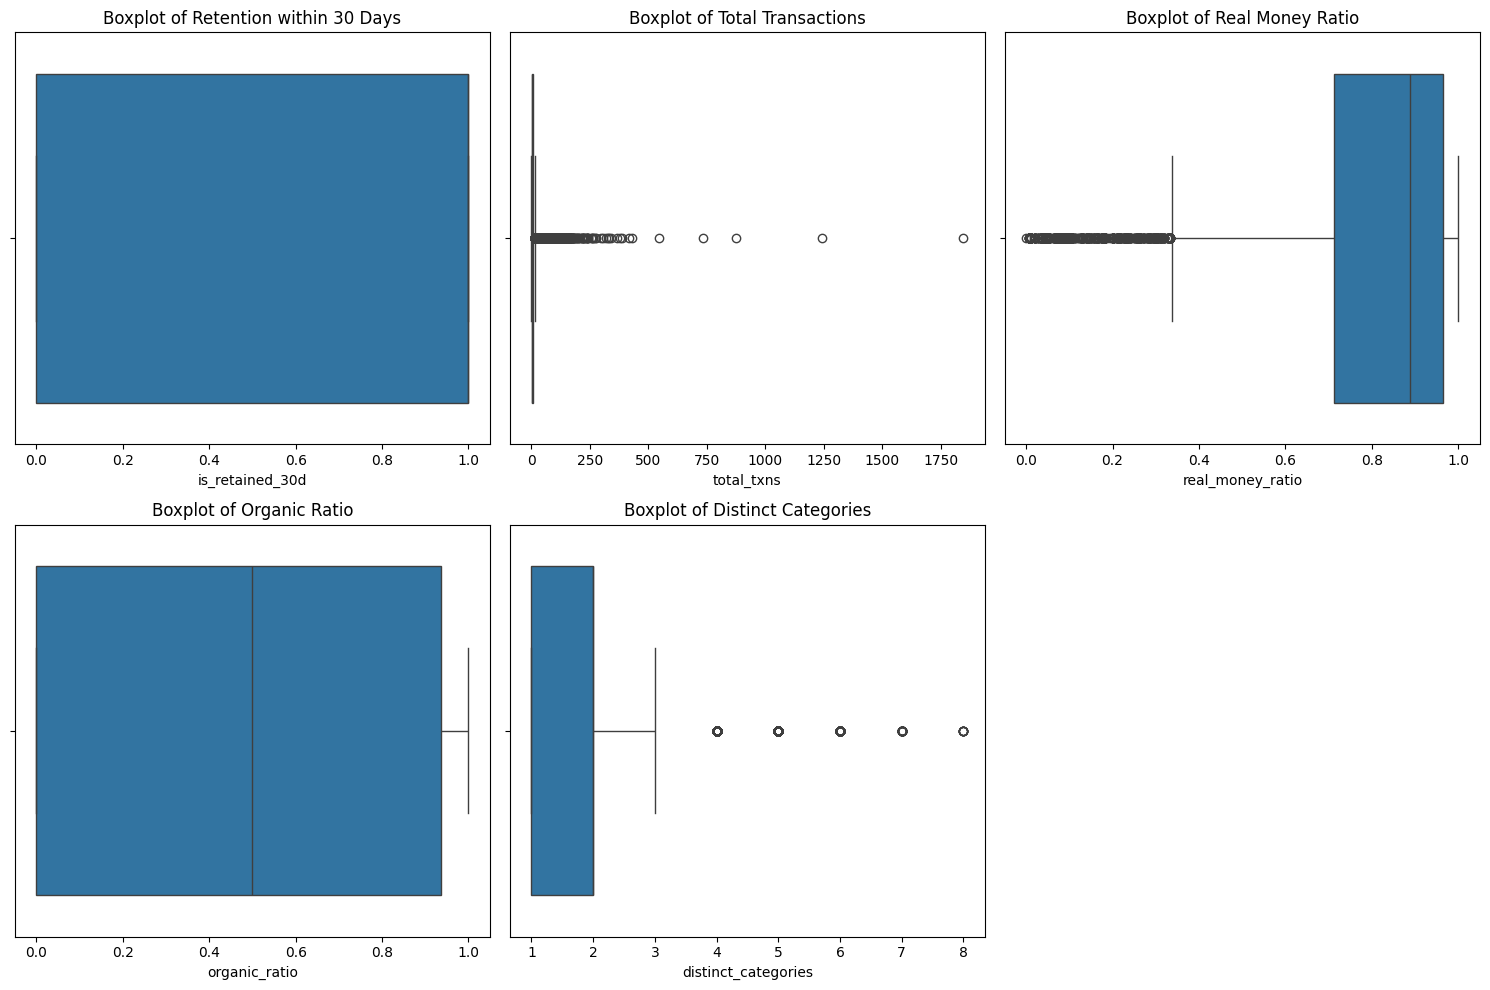

In [37]:
# Xem thống kê mô tả và phân phối boxplot cho của các feature mới tạo để hiểu rõ hơn về phân phối và giá trị của chúng
print("Thống kê mô tả của các feature mới:")
print(first_requests[['is_retained_30d', 'total_txns', 'real_money_ratio', 'organic_ratio', 'distinct_categories']].describe())

# Vẽ boxplot cho các feature mới để xem phân phối và outliers
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
sns.boxplot(x=first_requests['is_retained_30d'])
plt.title('Boxplot of Retention within 30 Days')
plt.subplot(2, 3, 2)
sns.boxplot(x=first_requests['total_txns'])
plt.title('Boxplot of Total Transactions')
plt.subplot(2, 3, 3)
sns.boxplot(x=first_requests['real_money_ratio'])
plt.title('Boxplot of Real Money Ratio')
plt.subplot(2, 3, 4)
sns.boxplot(x=first_requests['organic_ratio'])
plt.title('Boxplot of Organic Ratio')
plt.subplot(2, 3, 5)
sns.boxplot(x=first_requests['distinct_categories'])
plt.title('Boxplot of Distinct Categories')
plt.tight_layout()
plt.show()

Bước 3: User Segmentation (Phân loại chất lượng NPU)
Sử dụng các mốc phân vị (quartiles) hoặc logic tĩnh (rule-based) để dán nhãn cho từng userID:

Thợ săn voucher: real_money_ratio < 20% và organic_ratio < 10%.

Khách qua đường: total_txns = 1.

Tinh hoa: is_retained_30d = 1, real_money_ratio > 70%, distinct_categories >= 2.

In [38]:
# NPU quality segment rules
def _segment(row):
    # 1. Nhóm Khách qua đường (Churned/Passerby)
    if row['total_txns'] == 1:
        return 'Passerby'
    
    # 2. Nhóm Tinh hoa (Elite) - Siết chặt điều kiện để lọc Top user
    if (row['is_retained_30d'] == 1 and 
        row['total_txns'] >= 4 and 
        row['real_money_ratio'] >= 0.90 and 
        row['organic_ratio'] >= 0.50 and 
        row['distinct_categories'] >= 2):
        return 'Elite'
    
    # 3. Nhóm Thợ săn (Voucher Hunter) - Nới lỏng để bắt đúng tệp săn sale (Bottom 25%)
    if row['organic_ratio'] <= 0.1 and row['real_money_ratio'] < 0.75:
        return 'Voucher Hunter'
    
    # 4. Nhóm Phổ thông (Standard)
    return 'Standard'

# Áp dụng hàm vào DataFrame
first_requests['npu_quality_segment'] = first_requests.apply(_segment, axis=1)

# In ra vài dòng đầu tiên để kiểm tra kết quả phân nhóm
print(first_requests[['userID', 'is_retained_30d', 'total_txns', 'real_money_ratio', 'organic_ratio', 'distinct_categories', 'npu_quality_segment']].head(20))

                              userID  is_retained_30d  total_txns  \
0   000046fd1fef54ddbc605a4a98594da3                1           9   
1   00041140a6444358e88a665adc1aff3b                0           1   
2   0004fb19c9d26beda2b02c76c9fb8a1a                0           3   
3   000997f09e9e4101e1e0f74e8893031c                1           2   
4   000a20b1bef93304f99678268b912e4d                1           5   
5   000f5629750e9abf4dd962d7fa7ab146                1          21   
6   000f9fe208718884b73d9b5cc8487b23                0           9   
7   000fea8c3d3cc5c17238701d90e49f49                0           4   
8   0011e45275130f7a623c6abc8ed51bcb                1           5   
9   001496367691c7115fc4a0886ac563c7                1          11   
10  001611432f5e22dd3e2985ecc4f0b3ad                0           1   
11  0017a2320ca622452fe4f92d75645bcc                0           1   
12  00181d5e5d75ee7d087d8a4985dc944f                1          23   
13  0019a5403446ebbb9194447f527bcf

Bước 4: Campaign Aggregation (Tổng hợp lên cấp độ Chiến dịch)
Dùng .groupby('campaignID') để tạo ra bảng Đánh giá Chiến dịch. Tính các chỉ số:
Nhóm 1: Biến Tổng quan Chiến dịch (Campaign Metadata & Scale)
Nhóm biến này phác họa quy mô và bức tranh tài chính chung của chiến dịch.

campaign_duration (Số ngày chạy): Lấy Max(reqDate) - Min(reqDate) của chiến dịch. Rất quan trọng để tính toán vận tốc.

total_users (Tổng lượng người dùng): Tổng số unique userID tham gia chiến dịch (Bao gồm cả NPU và EPU).

total_promo_cost (Tổng chi phí khuyến mãi): Tổng giá trị cột discountAmount đã phát ra.

total_real_money (Tổng doanh thu thật): Tổng tiền người dùng tự nạp (userChargeAmount) trong thời gian chiến dịch.

overall_roi (Tỷ suất hoàn vốn chung): total_real_money / total_promo_cost. Cứ 1 đồng khuyến mãi vung ra, thu về bao nhiêu đồng tiền thật.

Nhóm 2: Biến Đánh giá Sức mạnh Thu hút (NPU Acquisition Features)
Nhóm biến này bóc tách riêng tệp NPU để xem chiến dịch "câu" được người mới tốt đến đâu.

npu_volume (Số lượng NPU): Tổng số lượng NPU mới mang về.

npu_acquisition_velocity (Vận tốc thu hút): npu_volume / campaign_duration. Trung bình mỗi ngày mang về bao nhiêu NPU. (Giúp so sánh công bằng giữa chiến dịch chạy 1 tháng và 2 tháng).

npu_elite_ratio (Tỷ lệ NPU Tinh hoa): Số lượng NPU được dán nhãn "Elite 30D" / npu_volume. Khẳng định chất lượng mồi câu.

npu_hunter_ratio (Tỷ lệ NPU Thợ săn): Số lượng NPU bị dán nhãn "Voucher Hunter 30D" / npu_volume. Đo lường mức độ rác của chiến dịch.

npu_avg_retention_rate (Tỷ lệ giữ chân NPU trung bình): Trung bình cộng biến is_retained_30d của tập NPU.

Nhóm 3: Biến Đánh giá Khả năng Khai thác (EPU Upsell Features)
Nhóm biến này bóc tách riêng tệp người dùng cũ để xem chiến dịch vắt được thêm bao nhiêu giá trị từ họ.

epu_volume (Số lượng EPU): Tổng số lượng EPU quay lại xài app nhờ chiến dịch.

epu_contribution_ratio (Tỷ trọng EPU): epu_volume / total_users. Xem chiến dịch này mang tính "đánh thức người cũ" nhiều hay "hút người mới" nhiều.

epu_arpu (Doanh thu trung bình trên mỗi EPU): Tổng userChargeAmount của tệp EPU / epu_volume.

epu_reactivation_count (Số lượng "gọi hồn" thành công - Tùy chọn nâng cao): Đếm số lượng EPU có khoảng cách từ lần giao dịch gần nhất trước đó đến chiến dịch này > 90 ngày.

Nhóm 4: Biến Chốt hạ (The North Star Metrics)
Đây là các biến tổng hợp dùng để vẽ lên ma trận và xếp hạng trực tiếp.

npu_quality_score (Điểm chất lượng NPU): Chấm theo thang 100, tổng hợp từ R.E.M.P.B của nhóm NPU.

epu_quality_score (Điểm chất lượng EPU): Chấm theo thang 100, dựa trên ARPU và Tần suất giao dịch của nhóm EPU.

total_cqi (Campaign Quality Index - Chỉ số chất lượng toàn diện): Ví dụ: (npu_quality_score * 0.6) + (epu_quality_score * 0.4). Điểm số duy nhất quyết định chiến dịch nào đang đứng Top 1.

In [40]:
import pandas as pd
import numpy as np

# =====================================================================
# BƯỚC 1: TIỀN XỬ LÝ TRÊN BẢNG DATA GỐC (MASTER TABLE)
# =====================================================================
# 1. Sắp xếp dữ liệu để tính toán lịch sử theo trục thời gian
data = data.sort_values(by=['userID', 'reqDate']).copy()

# 2. Tính khoảng cách "Ngủ đông" trên toàn bộ lịch sử (Để tránh bị sót giao dịch tự nhiên)
data['prev_reqDate'] = data.groupby('userID')['reqDate'].shift(1)
data['gap_days'] = (data['reqDate'] - data['prev_reqDate']).dt.days

# 3. Gán nhãn NPU (first_request) 
data['days_between'] = (data['reqDate'] - data['created_account_date']).dt.days
data['first_request'] = (data.groupby('userID').cumcount() == 0) & (data['days_between'] >= 0)

# Loại bỏ những user có giao dịch đầu tiên là Organic (campaignID == 0) ra khỏi tập đánh giá
data = data[~((data['first_request'] == True) & (data['campaignID'] == 0))].copy()

# Lấy riêng tập NPU hợp lệ
first_requests = data[data['first_request'] == True].copy()


# =====================================================================
# BƯỚC 2: TẠO "CHẬU KÍNH 30 NGÀY" VÀ TÍNH CHỈ SỐ R.E.M.P.B TOÀN DIỆN
# =====================================================================
# 1. Map ngày NPU vào toàn bộ giao dịch của user đó
npu_dates = first_requests[['userID', 'reqDate']].rename(columns={'reqDate': 'npu_date'})
data_with_npu = data.merge(npu_dates, on='userID', how='inner') # Chỉ giữ lại những user đã là NPU hợp lệ

# 2. Cắt cúp dữ liệu đúng 30 ngày kể từ ngày NPU để phục vụ phân khúc chất lượng ngắn hạn
data_with_npu['days_since_npu'] = (data_with_npu['reqDate'] - data_with_npu['npu_date']).dt.days
data_30d = data_with_npu[(data_with_npu['days_since_npu'] >= 0) & (data_with_npu['days_since_npu'] <= 30)].copy()

# 3. Tính toán Feature NGẮN HẠN (Trong 30 ngày đầu)
second_req_date = data_30d.groupby('userID')['reqDate'].apply(lambda x: x.iloc[1] if len(x) >= 2 else pd.NaT)
is_retained_30d = second_req_date.notna().astype(int).rename('is_retained_30d')
total_txns_30d = data_30d.groupby('userID').size().rename('total_txns_30d')

sum_charge_30d = data_30d.groupby('userID')['userChargeAmount'].sum()
sum_amount_30d = data_30d.groupby('userID')['amount'].sum()
real_money_ratio_30d = (sum_charge_30d / sum_amount_30d).fillna(0).rename('real_money_ratio_30d')

post_npu_30d = data_30d[data_30d['first_request'] == False]
post_counts_30d = post_npu_30d.groupby('userID').size()
organic_counts_30d = post_npu_30d[post_npu_30d['campaignID'] == 0].groupby('userID').size()
organic_ratio_30d = (organic_counts_30d / post_counts_30d).fillna(0).rename('organic_ratio_30d')

distinct_categories_30d = data_30d.groupby('userID')['report_cat'].nunique().rename('distinct_categories_30d')

MDR_RATE = 0.01  # Giả định biên lợi nhuận MDR là 1%
cac_cost_30d = data_30d[data_30d['first_request'] == True].groupby('userID')['discountAmount'].sum().rename('cac_cost_30d')
crc_cost_30d = data_30d[data_30d['first_request'] == False].groupby('userID')['discountAmount'].sum().rename('crc_cost_30d')
gross_ltv_30d = (sum_amount_30d * MDR_RATE).rename('gross_ltv_30d')


# 4. [MỚI BỔ SUNG] Tính toán tài chính TOÀN THỜI GIAN (Không giới hạn 30 ngày) cho từng User
sum_amount_total = data_with_npu.groupby('userID')['amount'].sum()
cac_cost_total = data_with_npu[data_with_npu['first_request'] == True].groupby('userID')['discountAmount'].sum().rename('cac_cost_total')
crc_cost_total = data_with_npu[data_with_npu['first_request'] == False].groupby('userID')['discountAmount'].sum().rename('crc_cost_total')
gross_ltv_total = (sum_amount_total * MDR_RATE).rename('gross_ltv_total')


# 5. Gộp TẤT CẢ các đặc trưng (Ngắn hạn + Toàn thời gian) vào bảng tổng hợp
user_features_all = pd.concat([
    is_retained_30d, total_txns_30d, real_money_ratio_30d, organic_ratio_30d, distinct_categories_30d,
    cac_cost_30d, crc_cost_30d, gross_ltv_30d,
    cac_cost_total, crc_cost_total, gross_ltv_total
], axis=1).reset_index()

# Điền giá trị 0 cho các ô trống tài chính
money_cols = ['cac_cost_30d', 'crc_cost_30d', 'gross_ltv_30d', 'cac_cost_total', 'crc_cost_total', 'gross_ltv_total']
user_features_all[money_cols] = user_features_all[money_cols].fillna(0)

# Merge toàn bộ vào bảng đầu ra first_requests
first_requests = first_requests.merge(user_features_all, on='userID', how='left')
first_requests[['organic_ratio_30d', 'real_money_ratio_30d']] = first_requests[['organic_ratio_30d', 'real_money_ratio_30d']].fillna(0)


# 6. Hạch toán dòng tiền ròng cho 2 mốc thời gian riêng biệt
# Lợi nhuận ròng thu về trong tháng đầu tiên
first_requests['net_ltv_30d'] = first_requests['gross_ltv_30d'] - first_requests['cac_cost_30d'] - first_requests['crc_cost_30d']

# [MỚI BỔ SUNG] Tổng lợi nhuận ròng thực tế mang lại từ trước đến nay
first_requests['total_net_ltv'] = first_requests['gross_ltv_total'] - first_requests['cac_cost_total'] - first_requests['crc_cost_total']

# Giữ lại hạch toán giao dịch đầu để làm báo cáo đối chiếu nhanh
first_requests['gross_revenue'] = first_requests['amount'] * MDR_RATE
first_requests['cac_cost'] = first_requests['discountAmount'] 
first_requests['net_revenue_txn1'] = first_requests['gross_revenue'] - first_requests['cac_cost']

# =====================================================================
# BƯỚC 3: DÁN NHÃN NPU BẰNG HÀM _segment_30d
# =====================================================================
def _segment_30d(row):
    if row['total_txns_30d'] == 1:
        return 'Passerby'
    if (row['is_retained_30d'] == 1 and 
        row['total_txns_30d'] >= 4 and 
        row['real_money_ratio_30d'] >= 0.90 and 
        row['organic_ratio_30d'] >= 0.50 and 
        row['distinct_categories_30d'] >= 2):
        return 'Elite'
    if row['organic_ratio_30d'] <= 0.1 and row['real_money_ratio_30d'] < 0.75:
        return 'Voucher Hunter'
    return 'Standard'

first_requests['npu_quality_segment'] = first_requests.apply(_segment_30d, axis=1)


# =====================================================================
# BƯỚC 4: TỔNG HỢP CHIẾN DỊCH (CAMPAIGN AGGREGATION) - BẢN CẬP NHẬT LTV TOTAL
# =====================================================================
# 1. Base Campaign (Bỏ các giao dịch Organic ra khỏi bảng xếp hạng Campaign)
campaign_base = data[data['campaignID'] != 0].copy()

# A. Scale & Duration & Campaign P&L (Toàn bộ chiến dịch)
campaign_dates = campaign_base.groupby('campaignID')['reqDate'].agg(['min', 'max'])
campaign_dates['campaign_duration'] = (campaign_dates['max'] - campaign_dates['min']).dt.days + 1
campaign_dates = campaign_dates.drop(columns=['min', 'max'])

campaign_scale = campaign_base.groupby('campaignID').agg(
    total_users=('userID', 'nunique'),
    total_promo_cost=('discountAmount', 'sum'),
    total_real_money=('userChargeAmount', 'sum'),
    total_amount=('amount', 'sum') 
)

# Tính toán Doanh thu và Lợi nhuận ròng sổ cái của TOÀN BỘ chiến dịch
campaign_scale['total_gross_revenue'] = campaign_scale['total_amount'] * MDR_RATE
campaign_scale['campaign_total_net_profit'] = campaign_scale['total_gross_revenue'] - campaign_scale['total_promo_cost']

# Tính Toán ROI toàn thời gian cho chiến dịch
campaign_scale['overall_roi'] = np.where(
    campaign_scale['total_promo_cost'] > 0,
    (campaign_scale['total_gross_revenue'] - campaign_scale['total_promo_cost']) / campaign_scale['total_promo_cost'],
    0
)


# B. NPU Metrics (Theo dõi vòng đời tệp khách hàng MỚI)
npu_base = first_requests[first_requests['campaignID'] != 0].copy()

# [CẬP NHẬT] Gom cả chỉ số 30 ngày lẫn TOÀN THỜI GIAN của tệp NPU lên cấp chiến dịch
npu_agg = npu_base.groupby('campaignID').agg(
    npu_volume=('userID', 'nunique'),
    npu_avg_retention_rate=('is_retained_30d', 'mean'),
    camp_total_cac_30d=('cac_cost_30d', 'sum'),        # Tiền mua khách (CAC)
    camp_total_crc_30d=('crc_cost_30d', 'sum'),        # Tiền nuôi khách 30 ngày (CRC 30d)
    camp_gross_ltv_30d=('gross_ltv_30d', 'sum'),        # Doanh thu gộp 30 ngày
    camp_net_ltv_30d=('net_ltv_30d', 'sum'),            # Lợi nhuận ròng 30 ngày của NPU
    camp_gross_ltv_total=('gross_ltv_total', 'sum'),    # Doanh thu gộp toàn thời gian của NPU
    camp_total_net_ltv=('total_net_ltv', 'sum')         # [MỚI VÀ QUAN TRỌNG] Tổng lợi nhuận ròng toàn thời gian của tệp NPU
)

npu_seg = npu_base.groupby('campaignID')['npu_quality_segment'].value_counts().unstack(fill_value=0)
npu_elite_ratio = (npu_seg.get('Elite', 0) / npu_seg.sum(axis=1)).rename('npu_elite_ratio')
npu_hunter_ratio = (npu_seg.get('Voucher Hunter', 0) / npu_seg.sum(axis=1)).rename('npu_hunter_ratio')
npu_agg = npu_agg.join([npu_elite_ratio, npu_hunter_ratio], how='left')


# C. EPU Metrics (Loại bỏ NPU của chính chiến dịch đó)
npu_users_per_camp = npu_base[['campaignID', 'userID']].drop_duplicates()
npu_users_per_camp['is_npu_of_this_camp'] = True

campaign_base = campaign_base.merge(npu_users_per_camp, on=['campaignID', 'userID'], how='left')
campaign_base['is_npu_of_this_camp'] = campaign_base['is_npu_of_this_camp'] == True

epu_base = campaign_base[campaign_base['is_npu_of_this_camp'] == False].copy()
epu_agg = epu_base.groupby('campaignID').agg(
    epu_volume=('userID', 'nunique'),
    epu_real_money=('userChargeAmount', 'sum')
)
epu_agg['epu_arpu'] = epu_agg['epu_real_money'] / epu_agg['epu_volume'].replace(0, pd.NA)

# Re-activation (Gọi hồn)
epu_base['is_reactivated'] = epu_base['gap_days'] > 90
epu_reactivate = epu_base[epu_base['is_reactivated']].groupby('campaignID')['userID'].nunique().rename('epu_reactivation_count')
epu_agg = epu_agg.join(epu_reactivate, how='left')


# =====================================================================
# BƯỚC 5: COMBINE VÀ CHẤM ĐIỂM (CQI SCORING)
# =====================================================================
campaign_df = campaign_dates.join(campaign_scale, how='outer')
campaign_df = campaign_df.join(npu_agg, how='outer')
campaign_df = campaign_df.join(epu_agg, how='outer')

# [CẬP NHẬT] Điền giá trị 0 cho các cột mới bổ sung để tránh lỗi rỗng (NaN)
cols_to_fill = [
    'npu_volume', 'epu_volume', 'epu_reactivation_count', 'total_users', 
    'npu_avg_retention_rate', 'npu_elite_ratio', 'npu_hunter_ratio', 'overall_roi',
    'camp_total_cac_30d', 'camp_total_crc_30d', 'camp_gross_ltv_30d', 'camp_net_ltv_30d',
    'camp_gross_ltv_total', 'camp_total_net_ltv', 'campaign_total_net_profit'
]
for col in cols_to_fill:
    if col in campaign_df.columns:
        campaign_df[col] = campaign_df[col].fillna(0)

# Các tỷ lệ phái sinh phục vụ vẽ Dashboard
campaign_df['npu_acquisition_velocity'] = campaign_df['npu_volume'] / campaign_df['campaign_duration'].replace(0, pd.NA)
campaign_df['epu_contribution_ratio'] = campaign_df['epu_volume'] / campaign_df['total_users'].replace(0, pd.NA)

# Dán nhãn trực quan cho Power BI
campaign_df['campaign_name'] = 'Camp_' + campaign_df.index.astype(str)
campaign_df['roi_status'] = np.where(campaign_df['overall_roi'] > 0, 'Lãi', 'Lỗ')

# Chấm điểm NPU (Trọng số 50-30-20) - Đã fix lỗi logic 20 điểm
campaign_df['npu_quality_score'] = np.where(
    campaign_df['npu_volume'] > 0,  # Điều kiện: Phải có NPU thì mới tính điểm
    (
        campaign_df['npu_avg_retention_rate'] * 0.5
        + campaign_df['npu_elite_ratio'] * 0.3
        + (1 - campaign_df['npu_hunter_ratio']) * 0.2
    ) * 100,
    0  # Nếu không có NPU nào, ép điểm về 0
)

# Chấm điểm EPU (Dựa trên ARPU chuẩn hóa theo Trung vị)
median_epu_arpu = campaign_df['epu_arpu'].median()
if pd.isna(median_epu_arpu) or median_epu_arpu == 0:
    campaign_df['epu_quality_score'] = 0
else:
    campaign_df['epu_quality_score'] = (campaign_df['epu_arpu'] / median_epu_arpu).clip(upper=1).fillna(0) * 100

# TÍNH BUSINESS IMPACT SCORE
rois = campaign_df['overall_roi'].fillna(0)
vols = campaign_df['total_users'].fillna(0)

norm_roi = (rois - rois.min()) / (rois.max() - rois.min() + 1e-9)
norm_vol = (vols - vols.min()) / (vols.max() - vols.min() + 1e-9)

campaign_df['business_impact_score'] = ((norm_roi * 0.5) + (norm_vol * 0.5)) * 100

# ĐIỂM CQI TỔNG HỢP
campaign_df['total_cqi'] = (
    (campaign_df['npu_quality_score'] * 0.4) 
    + (campaign_df['epu_quality_score'] * 0.2)
    + (campaign_df['business_impact_score'] * 0.4)
)

# Chốt sổ DataFrame và xuất file
campaign_df = campaign_df.reset_index()
campaign_df = campaign_df.sort_values(by='total_cqi', ascending=False)

campaign_df.to_csv('Data/Processed/campaign_quality_index.csv', index=False)
first_requests.to_csv('Data/Processed/first_requests.csv', index=False)

print("Đã xuất file thành công với đầy đủ các trường Total LTV!")

Đã xuất file thành công với đầy đủ các trường Total LTV!
